In [1]:
import os
import json
import random
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import pennylane as qml
import torch
import torch.nn as nn

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_recall_fscore_support,
    log_loss
)

warnings.filterwarnings("ignore")

In [2]:
RANDOM_STATE = 42

random.seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)
torch.manual_seed(RANDOM_STATE)

torch.set_default_dtype(torch.float32)

print("PennyLane:", qml.__version__)
print("PyTorch:", torch.__version__)

PennyLane: 0.45.1
PyTorch: 2.13.0+cpu


In [3]:
data_file = "quantum_encoded_healthcare_data.xlsx"

model_file = (
    "optimized_variational_quantum_model.pt"
)

noise_file = (
    "quantum_noise_simulation_results.xlsx"
)

output_file = (
    "robustness_reliability_analysis_results.xlsx"
)

configuration_file = (
    "robustness_reliability_configuration.json"
)

required_files = [
    data_file,
    model_file,
    noise_file
]

for file_name in required_files:
    if not os.path.exists(file_name):
        raise FileNotFoundError(
            f"{file_name} was not found."
        )

print("All required files are available.")

All required files are available.


In [4]:
X_test_df = pd.read_excel(
    data_file,
    sheet_name="X_Test_Quantum"
)

y_test_df = pd.read_excel(
    data_file,
    sheet_name="Y_Test"
)

class_mapping = pd.read_excel(
    data_file,
    sheet_name="Class_Mapping"
)

X_test = X_test_df.to_numpy(
    dtype=np.float32
)

y_test = y_test_df[
    "encoded_target"
].to_numpy(dtype=np.int64)

print("Test features:", X_test.shape)
print("Test targets:", y_test.shape)

Test features: (100, 4)
Test targets: (100,)


In [5]:
noise_metrics = pd.read_excel(
    noise_file,
    sheet_name="Noise_Metrics"
)

robustness_summary = pd.read_excel(
    noise_file,
    sheet_name="Robustness_Summary"
)

print("Noise simulations:", len(noise_metrics))

display(noise_metrics.head())

Noise simulations: 16


,simulation,noise_model,noise_probability,simulation_seconds,accuracy,balanced_accuracy,macro_precision,macro_recall,macro_f1,weighted_f1,top_3_accuracy,mean_confidence,accuracy_change,macro_f1_change,top_3_accuracy_change,confidence_change,prediction_stability
0,none_0.000,none,0.000,0.202619,0.27,0.250331,0.243782,0.250331,0.197958,0.207900,0.63,0.274564,0.00,0.000000,0.00,0.000000,1.00
1,depolarizing_0.001,depolarizing,0.001,0.111486,0.27,0.250331,0.243782,0.250331,0.197958,0.207900,0.63,0.273668,0.00,0.000000,0.00,-0.000896,1.00
2,depolarizing_0.005,depolarizing,0.005,0.111013,0.26,0.239914,0.234358,0.239914,0.187420,0.197603,0.64,0.270083,-0.01,-0.010537,0.01,-0.004481,0.99
3,depolarizing_0.010,depolarizing,0.010,0.104228,0.26,0.239914,0.234358,0.239914,0.187420,0.197603,0.64,0.265610,-0.01,-0.010537,0.01,-0.008954,0.99
4,depolarizing_0.020,depolarizing,0.020,0.098110,0.26,0.239914,0.235579,0.239914,0.186733,0.197125,0.65,0.256751,-0.01,-0.011224,0.02,-0.017813,0.97


In [6]:
try:
    checkpoint = torch.load(
        model_file,
        map_location="cpu",
        weights_only=False
    )
except TypeError:
    checkpoint = torch.load(
        model_file,
        map_location="cpu"
    )

selected_circuit = checkpoint["circuit_name"]
selected_template = checkpoint["template"]
selected_layers = int(checkpoint["layers"])
n_qubits = int(checkpoint["n_qubits"])
n_classes = int(checkpoint["n_classes"])
weight_shapes = checkpoint["weight_shapes"]

print("Circuit:", selected_circuit)
print("Template:", selected_template)
print("Layers:", selected_layers)
print("Qubits:", n_qubits)
print("Classes:", n_classes)

assert X_test.shape[1] == n_qubits

Circuit: Basic_2_Layers
Template: basic
Layers: 2
Qubits: 4
Classes: 12


In [7]:
quantum_device = qml.device(
    "default.qubit",
    wires=n_qubits
)

wires = list(range(n_qubits))

@qml.qnode(
    quantum_device,
    interface="torch",
    diff_method="backprop"
)
def optimized_quantum_circuit(inputs, weights):
    qml.AngleEmbedding(
        features=inputs,
        wires=wires,
        rotation="Y"
    )

    if selected_template == "basic":
        qml.BasicEntanglerLayers(
            weights=weights,
            wires=wires,
            rotation=qml.RY
        )

    elif selected_template == "strong":
        qml.StronglyEntanglingLayers(
            weights=weights,
            wires=wires
        )

    else:
        raise ValueError(
            f"Unknown template: {selected_template}"
        )

    return [
        qml.expval(qml.PauliZ(wire))
        for wire in wires
    ]

In [8]:
class ReliabilityQuantumClassifier(nn.Module):
    def __init__(self):
        super().__init__()

        self.quantum_layer = qml.qnn.TorchLayer(
            optimized_quantum_circuit,
            weight_shapes
        )

        self.output_layer = nn.Linear(
            n_qubits,
            n_classes
        )

    def forward(self, inputs):
        quantum_features = self.quantum_layer(
            inputs
        )

        return self.output_layer(
            quantum_features
        )


model = ReliabilityQuantumClassifier()

model.load_state_dict(
    checkpoint["model_state_dict"]
)

model.eval()

print("Optimized model loaded successfully.")

Optimized model loaded successfully.


In [9]:
def predict_probabilities(
    model,
    features
):
    feature_tensor = torch.tensor(
        features,
        dtype=torch.float32
    )

    model.eval()

    with torch.no_grad():
        logits = model(feature_tensor)

        probabilities = torch.softmax(
            logits,
            dim=1
        ).cpu().numpy()

    return probabilities

In [10]:
baseline_probabilities = predict_probabilities(
    model,
    X_test
)

baseline_predictions = np.argmax(
    baseline_probabilities,
    axis=1
)

baseline_confidence = np.max(
    baseline_probabilities,
    axis=1
)

baseline_accuracy = accuracy_score(
    y_test,
    baseline_predictions
)

baseline_balanced_accuracy = (
    balanced_accuracy_score(
        y_test,
        baseline_predictions
    )
)

_, _, baseline_macro_f1, _ = (
    precision_recall_fscore_support(
        y_test,
        baseline_predictions,
        average="macro",
        zero_division=0
    )
)

print("Baseline accuracy:",
      round(baseline_accuracy, 4))

print("Baseline balanced accuracy:",
      round(baseline_balanced_accuracy, 4))

print("Baseline macro F1:",
      round(baseline_macro_f1, 4))

Baseline accuracy: 0.27
Baseline balanced accuracy: 0.2503
Baseline macro F1: 0.198


In [11]:
perturbation_levels = [
    0.00,
    0.01,
    0.05,
    0.10,
    0.20
]

number_of_repetitions = 20

print("Perturbation levels:", perturbation_levels)
print("Repetitions:", number_of_repetitions)

Perturbation levels: [0.0, 0.01, 0.05, 0.1, 0.2]
Repetitions: 20


In [12]:
perturbation_rows = []
rng = np.random.default_rng(RANDOM_STATE)

for perturbation_level in perturbation_levels:
    repetitions = (
        1
        if perturbation_level == 0
        else number_of_repetitions
    )

    for repetition in range(repetitions):
        if perturbation_level == 0:
            perturbed_features = X_test.copy()
        else:
            random_noise = rng.normal(
                loc=0.0,
                scale=perturbation_level,
                size=X_test.shape
            )

            perturbed_features = (
                X_test + random_noise
            )

            # Encoded angles must remain valid
            perturbed_features = np.clip(
                perturbed_features,
                -np.pi,
                np.pi
            ).astype(np.float32)

        probabilities = predict_probabilities(
            model,
            perturbed_features
        )

        predictions = np.argmax(
            probabilities,
            axis=1
        )

        accuracy = accuracy_score(
            y_test,
            predictions
        )

        balanced_accuracy = (
            balanced_accuracy_score(
                y_test,
                predictions
            )
        )

        _, _, macro_f1, _ = (
            precision_recall_fscore_support(
                y_test,
                predictions,
                average="macro",
                zero_division=0
            )
        )

        prediction_stability = np.mean(
            predictions == baseline_predictions
        )

        probability_shift = np.mean(
            np.abs(
                probabilities
                - baseline_probabilities
            )
        )

        perturbation_rows.append({
            "perturbation_level":
                perturbation_level,
            "repetition": repetition + 1,
            "accuracy": accuracy,
            "balanced_accuracy":
                balanced_accuracy,
            "macro_f1": macro_f1,
            "prediction_stability":
                prediction_stability,
            "mean_probability_shift":
                probability_shift,
            "mean_confidence": np.max(
                probabilities,
                axis=1
            ).mean()
        })

perturbation_results = pd.DataFrame(
    perturbation_rows
)

display(perturbation_results.head())

,perturbation_level,repetition,accuracy,balanced_accuracy,macro_f1,prediction_stability,mean_probability_shift,mean_confidence
0,0.00,1,0.27,0.250331,0.197958,1.00,0.000000,0.274564
1,0.01,1,0.27,0.250331,0.197958,1.00,0.000508,0.274736
2,0.01,2,0.25,0.228009,0.165273,0.97,0.000538,0.274453
3,0.01,3,0.27,0.250331,0.198032,0.99,0.000422,0.274458
4,0.01,4,0.26,0.239914,0.187420,0.99,0.000467,0.274589


In [13]:
perturbation_summary = (
    perturbation_results
    .groupby(
        "perturbation_level",
        as_index=False
    )
    .agg(
        mean_accuracy=("accuracy", "mean"),
        std_accuracy=("accuracy", "std"),
        mean_balanced_accuracy=(
            "balanced_accuracy",
            "mean"
        ),
        mean_macro_f1=("macro_f1", "mean"),
        std_macro_f1=("macro_f1", "std"),
        mean_prediction_stability=(
            "prediction_stability",
            "mean"
        ),
        minimum_prediction_stability=(
            "prediction_stability",
            "min"
        ),
        mean_probability_shift=(
            "mean_probability_shift",
            "mean"
        ),
        mean_confidence=(
            "mean_confidence",
            "mean"
        )
    )
)

perturbation_summary = (
    perturbation_summary.fillna(0)
)

perturbation_summary[
    "accuracy_change"
] = (
    perturbation_summary["mean_accuracy"]
    - baseline_accuracy
)

perturbation_summary[
    "macro_f1_change"
] = (
    perturbation_summary["mean_macro_f1"]
    - baseline_macro_f1
)

display(perturbation_summary)

,perturbation_level,mean_accuracy,std_accuracy,mean_balanced_accuracy,mean_macro_f1,std_macro_f1,mean_prediction_stability,minimum_prediction_stability,mean_probability_shift,mean_confidence,accuracy_change,macro_f1_change
0,0.00,0.2700,0.000000,0.250331,0.197958,0.000000,1.0000,1.00,0.000000,0.274564,0.0000,0.000000
1,0.01,0.2675,0.005501,0.247578,0.194151,0.008928,0.9950,0.97,0.000493,0.274540,-0.0025,-0.003807
2,0.05,0.2620,0.008944,0.241133,0.183090,0.014280,0.9645,0.94,0.002520,0.275093,-0.0080,-0.014868
3,0.10,0.2615,0.018994,0.239936,0.184216,0.021016,0.9015,0.84,0.005123,0.275060,-0.0085,-0.013742
4,0.20,0.2565,0.026808,0.237583,0.188693,0.026584,0.8150,0.72,0.010450,0.273373,-0.0135,-0.009265


In [14]:
def bootstrap_metric_intervals(
    targets,
    predictions,
    number_of_bootstraps=1000,
    confidence_level=0.95,
    random_state=42
):
    rng = np.random.default_rng(
        random_state
    )

    accuracy_values = []
    macro_f1_values = []

    sample_size = len(targets)

    for _ in range(number_of_bootstraps):
        sample_indices = rng.choice(
            sample_size,
            size=sample_size,
            replace=True
        )

        sampled_targets = targets[
            sample_indices
        ]

        sampled_predictions = predictions[
            sample_indices
        ]

        accuracy_values.append(
            accuracy_score(
                sampled_targets,
                sampled_predictions
            )
        )

        _, _, sampled_f1, _ = (
            precision_recall_fscore_support(
                sampled_targets,
                sampled_predictions,
                average="macro",
                zero_division=0
            )
        )

        macro_f1_values.append(sampled_f1)

    alpha = 1.0 - confidence_level

    return pd.DataFrame({
        "metric": [
            "accuracy",
            "macro_f1"
        ],
        "observed_value": [
            baseline_accuracy,
            baseline_macro_f1
        ],
        "lower_confidence_bound": [
            np.quantile(
                accuracy_values,
                alpha / 2
            ),
            np.quantile(
                macro_f1_values,
                alpha / 2
            )
        ],
        "upper_confidence_bound": [
            np.quantile(
                accuracy_values,
                1 - alpha / 2
            ),
            np.quantile(
                macro_f1_values,
                1 - alpha / 2
            )
        ],
        "confidence_level": [
            confidence_level,
            confidence_level
        ]
    })


bootstrap_intervals = (
    bootstrap_metric_intervals(
        y_test,
        baseline_predictions
    )
)

display(bootstrap_intervals)

,metric,observed_value,lower_confidence_bound,upper_confidence_bound,confidence_level
0,accuracy,0.270000,0.180000,0.360000,0.95
1,macro_f1,0.197958,0.122776,0.261068,0.95


In [15]:
def multiclass_brier_score(
    targets,
    probabilities,
    number_of_classes
):
    one_hot_targets = np.eye(
        number_of_classes
    )[targets]

    return np.mean(
        np.sum(
            (
                probabilities
                - one_hot_targets
            ) ** 2,
            axis=1
        )
    )


def expected_calibration_error(
    targets,
    predictions,
    probabilities,
    number_of_bins=10
):
    confidence = np.max(
        probabilities,
        axis=1
    )

    correct = (
        predictions == targets
    ).astype(float)

    bin_edges = np.linspace(
        0.0,
        1.0,
        number_of_bins + 1
    )

    ece = 0.0
    calibration_rows = []

    for bin_number in range(number_of_bins):
        lower_bound = bin_edges[bin_number]
        upper_bound = bin_edges[
            bin_number + 1
        ]

        if bin_number == 0:
            in_bin = (
                (confidence >= lower_bound)
                & (confidence <= upper_bound)
            )
        else:
            in_bin = (
                (confidence > lower_bound)
                & (confidence <= upper_bound)
            )

        bin_count = in_bin.sum()

        if bin_count > 0:
            bin_accuracy = correct[
                in_bin
            ].mean()

            bin_confidence = confidence[
                in_bin
            ].mean()

            bin_weight = (
                bin_count / len(targets)
            )

            gap = abs(
                bin_accuracy
                - bin_confidence
            )

            ece += bin_weight * gap

        else:
            bin_accuracy = np.nan
            bin_confidence = np.nan
            gap = np.nan

        calibration_rows.append({
            "bin": bin_number + 1,
            "lower_bound": lower_bound,
            "upper_bound": upper_bound,
            "sample_count": bin_count,
            "mean_confidence":
                bin_confidence,
            "observed_accuracy":
                bin_accuracy,
            "calibration_gap": gap
        })

    return ece, pd.DataFrame(
        calibration_rows
    )

In [16]:
brier_score = multiclass_brier_score(
    y_test,
    baseline_probabilities,
    n_classes
)

negative_log_likelihood = log_loss(
    y_test,
    baseline_probabilities,
    labels=np.arange(n_classes)
)

ece_score, calibration_table = (
    expected_calibration_error(
        y_test,
        baseline_predictions,
        baseline_probabilities,
        number_of_bins=10
    )
)

calibration_metrics = pd.DataFrame({
    "metric": [
        "Multiclass Brier score",
        "Negative log-likelihood",
        "Expected calibration error",
        "Mean prediction confidence"
    ],
    "value": [
        brier_score,
        negative_log_likelihood,
        ece_score,
        baseline_confidence.mean()
    ]
})

display(calibration_metrics)
display(calibration_table)

,metric,value
0,Multiclass Brier score,0.780770
1,Negative log-likelihood,1.777133
2,Expected calibration error,0.072035
3,Mean prediction confidence,0.274564


,bin,lower_bound,upper_bound,sample_count,mean_confidence,observed_accuracy,calibration_gap
0,1,0.0,0.1,0,NaN,NaN,NaN
1,2,0.1,0.2,34,0.166207,0.205882,0.039675
2,3,0.2,0.3,39,0.230139,0.282051,0.051913
3,4,0.3,0.4,5,0.352083,0.200000,0.152083
4,5,0.4,0.5,11,0.467313,0.272727,0.194586
5,6,0.5,0.6,11,0.539010,0.454545,0.084464
6,7,0.6,0.7,0,NaN,NaN,NaN
7,8,0.7,0.8,0,NaN,NaN,NaN
8,9,0.8,0.9,0,NaN,NaN,NaN
9,10,0.9,1.0,0,NaN,NaN,NaN


In [17]:
safe_probabilities = np.clip(
    baseline_probabilities,
    1e-12,
    1.0
)

prediction_entropy = -np.sum(
    safe_probabilities
    * np.log(safe_probabilities),
    axis=1
)

maximum_entropy = np.log(n_classes)

normalized_entropy = (
    prediction_entropy
    / maximum_entropy
)

uncertainty_results = pd.DataFrame({
    "test_record": np.arange(
        1,
        len(y_test) + 1
    ),
    "actual_class": y_test,
    "predicted_class":
        baseline_predictions,
    "prediction_correct": (
        y_test == baseline_predictions
    ),
    "confidence":
        baseline_confidence,
    "entropy":
        prediction_entropy,
    "normalized_entropy":
        normalized_entropy
})

uncertainty_results[
    "uncertainty_level"
] = pd.cut(
    uncertainty_results[
        "normalized_entropy"
    ],
    bins=[
        -np.inf,
        0.60,
        0.80,
        np.inf
    ],
    labels=[
        "Low uncertainty",
        "Moderate uncertainty",
        "High uncertainty"
    ]
)

display(uncertainty_results.head())

,test_record,actual_class,predicted_class,prediction_correct,confidence,entropy,normalized_entropy,uncertainty_level
0,1,9,4,False,0.216870,2.046604,0.823614,High uncertainty
1,2,2,2,True,0.531624,1.110359,0.446841,Low uncertainty
2,3,10,10,True,0.253485,2.227477,0.896403,High uncertainty
3,4,10,2,False,0.155397,2.334845,0.939611,High uncertainty
4,5,5,4,False,0.246902,1.894952,0.762585,Moderate uncertainty


In [18]:
confidence_thresholds = [
    0.00,
    0.15,
    0.20,
    0.25,
    0.30,
    0.40,
    0.50,
    0.60
]

selective_rows = []

for threshold in confidence_thresholds:
    selected = (
        baseline_confidence >= threshold
    )

    coverage = selected.mean()
    selected_count = selected.sum()

    if selected_count > 0:
        selective_accuracy = accuracy_score(
            y_test[selected],
            baseline_predictions[selected]
        )

        _, _, selective_f1, _ = (
            precision_recall_fscore_support(
                y_test[selected],
                baseline_predictions[selected],
                average="macro",
                zero_division=0
            )
        )
    else:
        selective_accuracy = np.nan
        selective_f1 = np.nan

    selective_rows.append({
        "confidence_threshold": threshold,
        "retained_predictions":
            selected_count,
        "coverage": coverage,
        "selective_accuracy":
            selective_accuracy,
        "selective_macro_f1":
            selective_f1,
        "referred_for_review":
            len(y_test) - selected_count
    })

selective_reliability = pd.DataFrame(
    selective_rows
)

display(selective_reliability)

,confidence_threshold,retained_predictions,coverage,selective_accuracy,selective_macro_f1,referred_for_review
0,0.00,100,1.00,0.270000,0.197958,0
1,0.15,93,0.93,0.279570,0.188186,7
2,0.20,66,0.66,0.303030,0.178180,34
3,0.25,32,0.32,0.375000,0.262001,68
4,0.30,27,0.27,0.333333,0.243165,73
5,0.40,22,0.22,0.363636,0.284722,78
6,0.50,11,0.11,0.454545,0.225275,89
7,0.60,0,0.00,NaN,NaN,100


In [19]:
per_class_rows = []

for class_id in range(n_classes):
    class_mask = y_test == class_id
    class_count = class_mask.sum()

    if class_count == 0:
        continue

    class_accuracy = np.mean(
        baseline_predictions[class_mask]
        == y_test[class_mask]
    )

    class_confidence = np.mean(
        baseline_confidence[class_mask]
    )

    class_entropy = np.mean(
        normalized_entropy[class_mask]
    )

    per_class_rows.append({
        "encoded_class": class_id,
        "sample_count": class_count,
        "class_recall": class_accuracy,
        "mean_confidence":
            class_confidence,
        "mean_normalized_entropy":
            class_entropy
    })

per_class_reliability = pd.DataFrame(
    per_class_rows
)

display(per_class_reliability)

,encoded_class,sample_count,class_recall,mean_confidence,mean_normalized_entropy
0,0,8,0.000000,0.196338,0.828703
1,1,7,0.000000,0.185743,0.854112
2,2,9,0.555556,0.535332,0.405834
3,3,8,0.375000,0.442515,0.518689
4,4,10,0.900000,0.200020,0.839607
5,5,8,0.000000,0.207832,0.852755
6,6,9,0.333333,0.397310,0.610011
7,7,9,0.222222,0.261123,0.834881
8,8,7,0.000000,0.209915,0.862009
9,9,10,0.100000,0.193292,0.860161


In [20]:
class_mapping.columns = (
    class_mapping.columns
    .astype(str)
    .str.strip()
    .str.lower()
    .str.replace(" ", "_")
    .str.replace("-", "_")
)

encoded_column = (
    "encoded_label"
    if "encoded_label" in class_mapping.columns
    else "encoded_target"
)

medicine_column = (
    "historical_medication_class"
)

mapping_dictionary = {
    int(encoded_value): str(medicine_class)
    for encoded_value, medicine_class in zip(
        class_mapping[encoded_column],
        class_mapping[medicine_column]
    )
}

per_class_reliability[
    "medication_class"
] = (
    per_class_reliability[
        "encoded_class"
    ].map(mapping_dictionary)
)

uncertainty_results[
    "actual_medication_class"
] = (
    uncertainty_results[
        "actual_class"
    ].map(mapping_dictionary)
)

uncertainty_results[
    "predicted_medication_class"
] = (
    uncertainty_results[
        "predicted_class"
    ].map(mapping_dictionary)
)

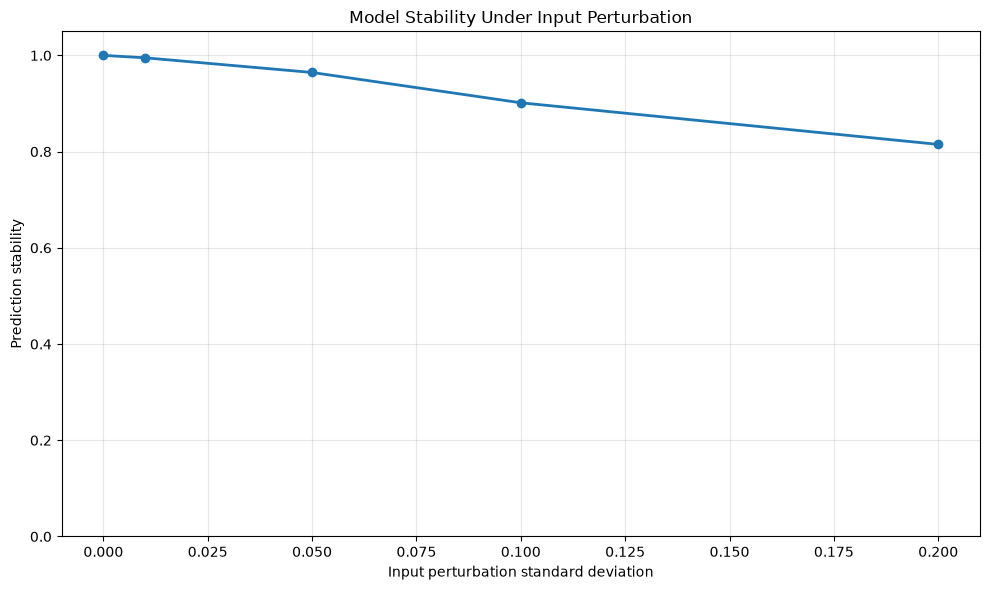

In [21]:
plt.figure(figsize=(10, 6))

plt.plot(
    perturbation_summary[
        "perturbation_level"
    ],
    perturbation_summary[
        "mean_prediction_stability"
    ],
    marker="o",
    linewidth=2
)

plt.ylim(0, 1.05)
plt.xlabel("Input perturbation standard deviation")
plt.ylabel("Prediction stability")
plt.title("Model Stability Under Input Perturbation")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

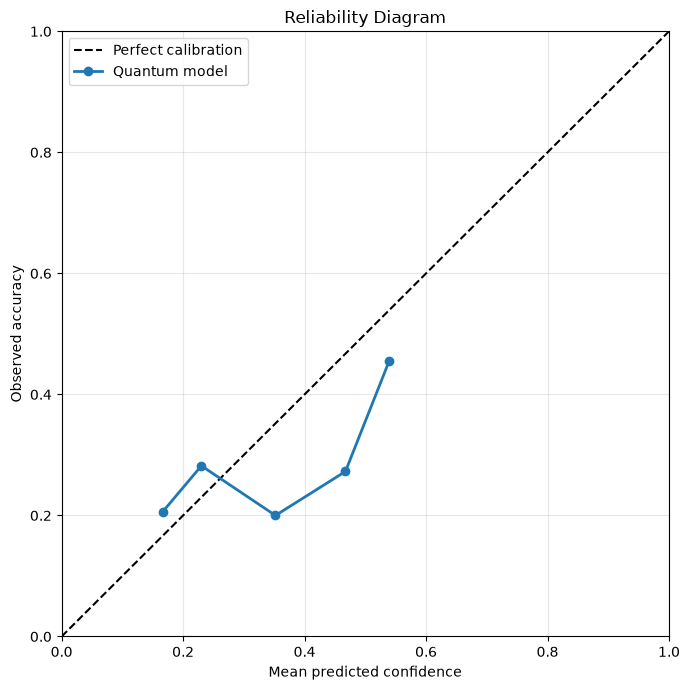

In [22]:
valid_calibration_bins = (
    calibration_table.dropna(
        subset=[
            "mean_confidence",
            "observed_accuracy"
        ]
    )
)

plt.figure(figsize=(7, 7))

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    color="black",
    label="Perfect calibration"
)

plt.plot(
    valid_calibration_bins[
        "mean_confidence"
    ],
    valid_calibration_bins[
        "observed_accuracy"
    ],
    marker="o",
    linewidth=2,
    label="Quantum model"
)

plt.xlabel("Mean predicted confidence")
plt.ylabel("Observed accuracy")
plt.title("Reliability Diagram")
plt.xlim(0, 1)
plt.ylim(0, 1)
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

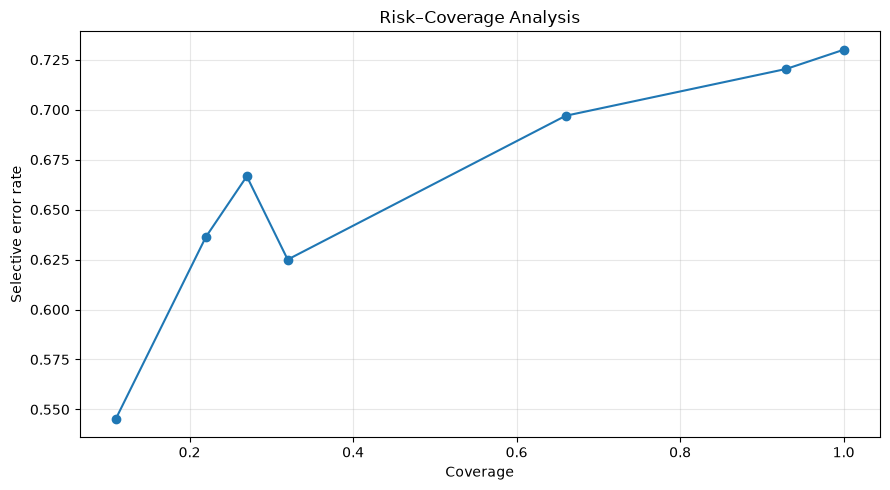

In [23]:
plot_selective = (
    selective_reliability.dropna(
        subset=["selective_accuracy"]
    )
)

plt.figure(figsize=(9, 5))

plt.plot(
    plot_selective["coverage"],
    1 - plot_selective[
        "selective_accuracy"
    ],
    marker="o"
)

plt.xlabel("Coverage")
plt.ylabel("Selective error rate")
plt.title("Risk–Coverage Analysis")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [24]:
highest_perturbation = (
    perturbation_summary
    .sort_values(
        "perturbation_level"
    )
    .iloc[-1]
)

worst_noise = (
    noise_metrics[
        noise_metrics["noise_model"]
        != "none"
    ]
    .sort_values("macro_f1")
    .iloc[0]
)

final_summary = pd.DataFrame({
    "measure": [
        "Baseline accuracy",
        "Baseline balanced accuracy",
        "Baseline macro F1",
        "Accuracy bootstrap lower bound",
        "Accuracy bootstrap upper bound",
        "Macro F1 bootstrap lower bound",
        "Macro F1 bootstrap upper bound",
        "Expected calibration error",
        "Multiclass Brier score",
        "Mean confidence",
        "Mean normalized entropy",
        "Highest perturbation tested",
        "Stability at highest perturbation",
        "Worst tested noise model",
        "Worst tested noise probability",
        "Worst-noise macro F1"
    ],
    "value": [
        baseline_accuracy,
        baseline_balanced_accuracy,
        baseline_macro_f1,
        bootstrap_intervals.loc[
            bootstrap_intervals["metric"]
            == "accuracy",
            "lower_confidence_bound"
        ].iloc[0],
        bootstrap_intervals.loc[
            bootstrap_intervals["metric"]
            == "accuracy",
            "upper_confidence_bound"
        ].iloc[0],
        bootstrap_intervals.loc[
            bootstrap_intervals["metric"]
            == "macro_f1",
            "lower_confidence_bound"
        ].iloc[0],
        bootstrap_intervals.loc[
            bootstrap_intervals["metric"]
            == "macro_f1",
            "upper_confidence_bound"
        ].iloc[0],
        ece_score,
        brier_score,
        baseline_confidence.mean(),
        normalized_entropy.mean(),
        highest_perturbation[
            "perturbation_level"
        ],
        highest_perturbation[
            "mean_prediction_stability"
        ],
        worst_noise["noise_model"],
        worst_noise["noise_probability"],
        worst_noise["macro_f1"]
    ]
})

display(final_summary)

,measure,value
0,Baseline accuracy,0.27
1,Baseline balanced accuracy,0.250331
2,Baseline macro F1,0.197958
3,Accuracy bootstrap lower bound,0.18
4,Accuracy bootstrap upper bound,0.36
5,Macro F1 bootstrap lower bound,0.122776
6,Macro F1 bootstrap upper bound,0.261068
7,Expected calibration error,0.072035
8,Multiclass Brier score,0.78077
9,Mean confidence,0.274564


In [25]:
assert baseline_probabilities.shape == (
    len(X_test),
    n_classes
)

assert np.allclose(
    baseline_probabilities.sum(axis=1),
    1.0,
    atol=1e-6
)

assert perturbation_summary[
    "mean_prediction_stability"
].between(0, 1).all()

assert selective_reliability[
    "coverage"
].between(0, 1).all()

assert uncertainty_results[
    "normalized_entropy"
].between(0, 1.000001).all()

assert 0 <= ece_score <= 1

print(
    "All robustness and reliability "
    "validation checks passed."
)

All robustness and reliability validation checks passed.


In [26]:
configuration = {
    "stage": "Robustness and Reliability Analysis",
    "input_model": model_file,
    "noise_input": noise_file,
    "selected_circuit": selected_circuit,
    "perturbation_levels":
        perturbation_levels,
    "perturbation_repetitions":
        number_of_repetitions,
    "bootstrap_samples": 1000,
    "bootstrap_confidence_level": 0.95,
    "calibration_bins": 10,
    "baseline_accuracy":
        float(baseline_accuracy),
    "baseline_macro_f1":
        float(baseline_macro_f1),
    "expected_calibration_error":
        float(ece_score),
    "brier_score":
        float(brier_score)
}

with open(configuration_file, "w") as file:
    json.dump(
        configuration,
        file,
        indent=4
    )

with pd.ExcelWriter(
    output_file,
    engine="openpyxl"
) as writer:

    final_summary.to_excel(
        writer,
        sheet_name="Reliability_Summary",
        index=False
    )

    perturbation_results.to_excel(
        writer,
        sheet_name="Perturbation_Runs",
        index=False
    )

    perturbation_summary.to_excel(
        writer,
        sheet_name="Perturbation_Summary",
        index=False
    )

    noise_metrics.to_excel(
        writer,
        sheet_name="Noise_Robustness",
        index=False
    )

    bootstrap_intervals.to_excel(
        writer,
        sheet_name="Bootstrap_Intervals",
        index=False
    )

    calibration_metrics.to_excel(
        writer,
        sheet_name="Calibration_Metrics",
        index=False
    )

    calibration_table.to_excel(
        writer,
        sheet_name="Calibration_Bins",
        index=False
    )

    selective_reliability.to_excel(
        writer,
        sheet_name="Selective_Reliability",
        index=False
    )

    per_class_reliability.to_excel(
        writer,
        sheet_name="Per_Class_Reliability",
        index=False
    )

    uncertainty_results.to_excel(
        writer,
        sheet_name="Prediction_Uncertainty",
        index=False
    )

    pd.DataFrame(
        list(configuration.items()),
        columns=["configuration", "value"]
    ).to_excel(
        writer,
        sheet_name="Configuration",
        index=False
    )

print("Saved results:", output_file)
print("Saved configuration:", configuration_file)

Saved results: robustness_reliability_analysis_results.xlsx
Saved configuration: robustness_reliability_configuration.json


In [27]:
for file_name in [
    output_file,
    configuration_file
]:
    print(
        file_name,
        "exists:",
        os.path.exists(file_name)
    )

saved_workbook = pd.ExcelFile(output_file)

print("\nSaved sheets:")
print(saved_workbook.sheet_names)

print("\nBaseline accuracy:",
      round(baseline_accuracy, 4))

print("Baseline macro F1:",
      round(baseline_macro_f1, 4))

print("Calibration error:",
      round(ece_score, 4))

print("Mean normalized entropy:",
      round(normalized_entropy.mean(), 4))

robustness_reliability_analysis_results.xlsx exists: True
robustness_reliability_configuration.json exists: True

Saved sheets:
['Reliability_Summary', 'Perturbation_Runs', 'Perturbation_Summary', 'Noise_Robustness', 'Bootstrap_Intervals', 'Calibration_Metrics', 'Calibration_Bins', 'Selective_Reliability', 'Per_Class_Reliability', 'Prediction_Uncertainty', 'Configuration']

Baseline accuracy: 0.27
Baseline macro F1: 0.198
Calibration error: 0.072
Mean normalized entropy: 0.7668
